### The code below this for accuracy, time, memory calculation

In [1]:
import pandas as pd
from IPython.display import display
output_filename = 'test.xlsx'

# Load the data from the Excel file
df_loaded = pd.read_excel(output_filename)
print(df_loaded)
print(f"Data loaded from {output_filename}:")

mean_row = df_loaded.mean().to_frame().T
std_row = df_loaded.std().to_frame().T

# Extract the Series from the single-row DataFrames
means = mean_row.iloc[0]
stds = std_row.iloc[0]

# Create a new dictionary to store the formatted results
formatted_mean_std = {}

# Iterate over the columns to format "Mean ± Std"
for col in means.index:
    formatted_mean_std[col] = f"{means[col]:.2f} \u00b1 {stds[col]:.2f}"

# Convert the dictionary to a Series for display
mean_std_series = pd.Series(formatted_mean_std, name='Mean \u00b1 Std')

# Display as a DataFrame with one row for better readability
display(mean_std_series.to_frame().T)

   magic_gamma_telescope        A9a  Run_or_walk_information    hepmass  \
0                1.06250  16.687500                 0.250000   8.578125   
1                1.21875  18.265625                 0.156250  34.343750   
2                0.78125  12.531250                 0.171875  19.093750   

         susy  
0  272.875000  
1  244.562500  
2  197.390625  
Data loaded from test.xlsx:


,magic_gamma_telescope,A9a,Run_or_walk_information,hepmass,susy
Mean ± Std,1.02 ± 0.22,15.83 ± 2.96,0.19 ± 0.05,20.67 ± 12.96,238.28 ± 38.13


### the code below this for loss frequency plot


Final values:
   label  mean       std
0  NCE3   1.6  1.341641
1  NCE2   6.2  3.346640
2  NCE1   0.6  0.894427
3   SR2  10.2  5.674504
4   SR1  38.2  7.049823
5   TLS   0.2  0.447214
6   TSH  43.0  5.244044
7   SQH   0.0  0.000000
8    SH   0.0  0.000000
9    LS   0.0  0.000000


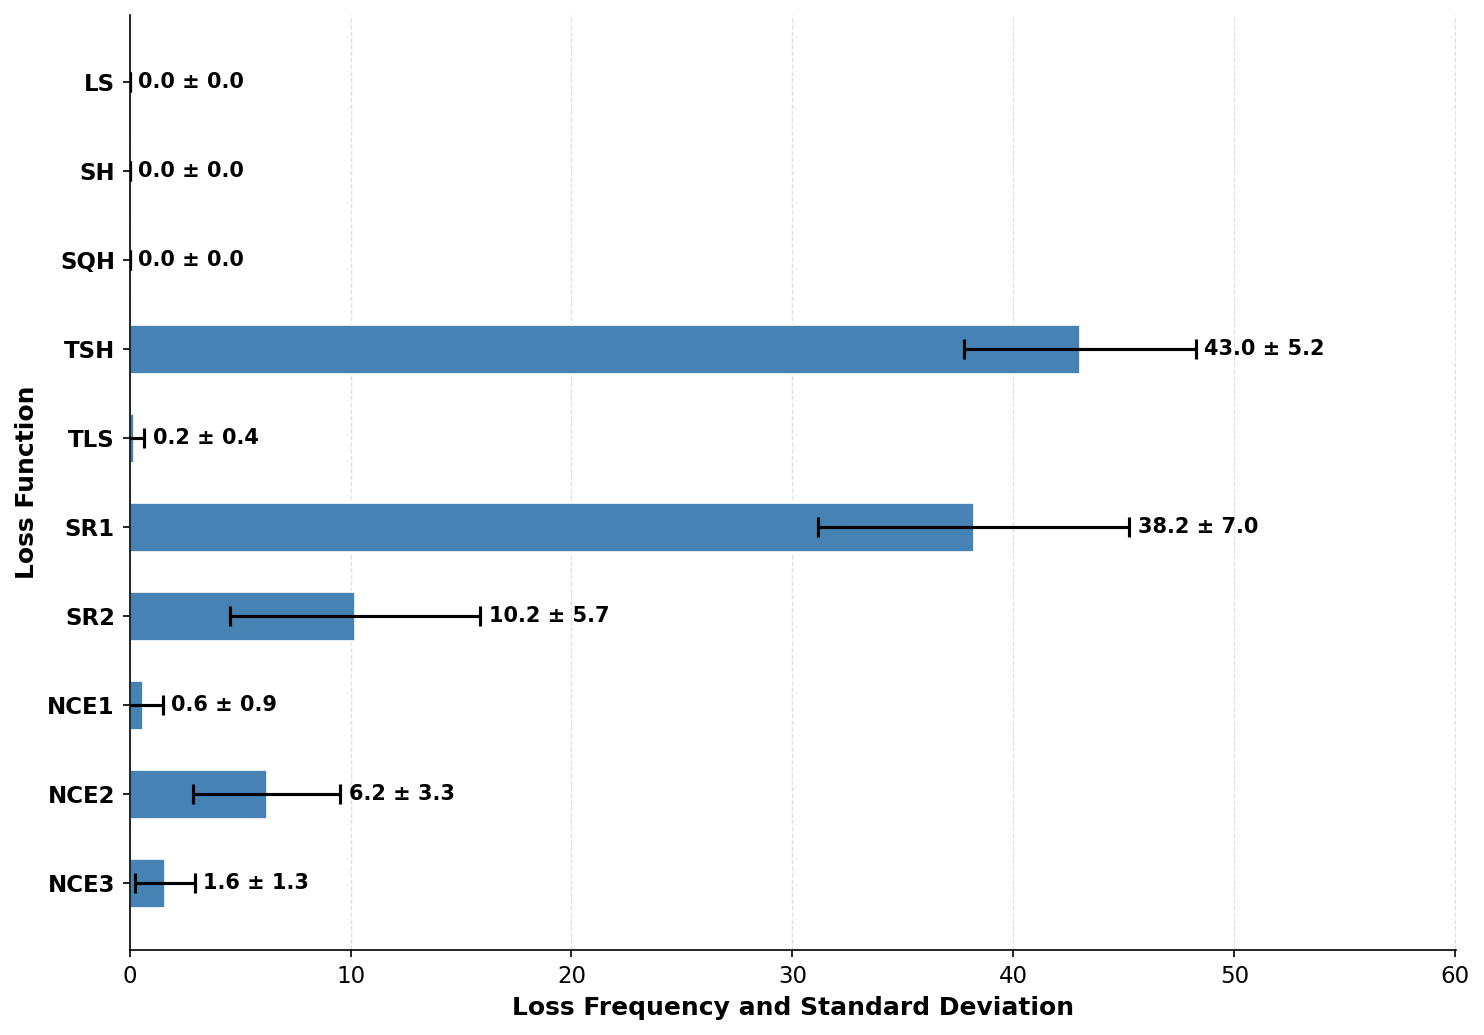

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────
#  USER CONTROLS
# ─────────────────────────────────────────────
EXCEL_FILE       = "test.xlsx"
SHEET_NAME       = 0
DATASET          = "mnist"

BAR_HEIGHT       = 0.55
BAR_COLOR        = "steelblue"
ERROR_BAR_COLOR  = "black"
ERROR_BAR_CAP    = 5

TITLE_FONTSIZE   = 14
AXIS_LABEL_SIZE  = 12
TICK_LABEL_SIZE  = 11
VALUE_LABEL_SIZE = 10
FONT_FAMILY      = "DejaVu Sans"
FONT_WEIGHT      = "bold"

FIG_WIDTH        = 10
FIG_HEIGHT       = 7
DPI              = 150
SAVE_PATH        = None   # e.g. "plot.png"
# ─────────────────────────────────────────────

SHORT_NAMES = {
    "Least Squares"       : "LS",
    "Smooth Hinge"        : "SH",
    "Squared Hinge"       : "SQH",
    "Truncated SH"        : "TSH",
    "Truncated LS"        : "TLS",
    "Smoothed Ramp1"      : "SR1",
    "Smoothed Ramp2"      : "SR2",
    "nonconvex exp loss1" : "NCE1",
    "nonconvex exp loss2" : "NCE2",
    "nonconvex exp loss3" : "NCE3",
}

# ── Load data ─────────────────────────────────
df = pd.read_excel(EXCEL_FILE, sheet_name=SHEET_NAME, header=0)

# Rename first two columns regardless of what they are called in Excel
df.rename(columns={df.columns[0]: "Dataset Name", df.columns[1]: "Loss"}, inplace=True)

# Remaining columns are seed runs
seed_cols = df.columns[2:].tolist()

# ── Filter dataset ────────────────────────────
df = df[df["Dataset Name"].str.strip().str.lower() == DATASET.lower()].copy()

if df.empty:
    raise ValueError(f"No rows found for dataset='{DATASET}'. Check spelling.")

# ── Compute mean & std across seed columns ────
df[seed_cols] = df[seed_cols].apply(pd.to_numeric, errors="coerce")
df["mean"]    = df[seed_cols].mean(axis=1)
df["std"]     = df[seed_cols].std(axis=1)
df["label"]   = df["Loss"].str.strip().map(SHORT_NAMES).fillna(df["Loss"].str.strip())

df = df.reset_index(drop=True)
df = df.iloc[::-1].reset_index(drop=True)

print("\nFinal values:\n", df[["label", "mean", "std"]])

# ── Plot ──────────────────────────────────────
plt.rcParams.update({"font.family": FONT_FAMILY})

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)

y_pos = np.arange(len(df))

ax.barh(
    y_pos,
    df["mean"],
    height    = BAR_HEIGHT,
    color     = BAR_COLOR,
    edgecolor = "white",
    linewidth = 0.8,
    xerr      = df["std"],
    error_kw  = dict(ecolor=ERROR_BAR_COLOR, capsize=ERROR_BAR_CAP,
                     elinewidth=1.5, capthick=1.5),
    zorder    = 2,
)

# Value label at the end of each bar
for i, (mean_val, std_val) in enumerate(zip(df["mean"], df["std"])):
    ax.text(
        mean_val + std_val + 0.4,
        y_pos[i],
        f"{mean_val:.1f} ± {std_val:.1f}",
        va="center", ha="left",
        fontsize=VALUE_LABEL_SIZE,
        fontweight=FONT_WEIGHT,
    )

# Y axis = loss names
ax.set_yticks(y_pos)
ax.set_yticklabels(df["label"], fontsize=TICK_LABEL_SIZE, fontweight=FONT_WEIGHT)

# X axis = error count
ax.set_xlabel("Loss Frequency and Standard Deviation", fontsize=AXIS_LABEL_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel("Loss Function", fontsize=AXIS_LABEL_SIZE, fontweight=FONT_WEIGHT)
# ax.set_title(f"Error Rate per Loss Function  [{DATASET.upper()}]",
#              fontsize=TITLE_FONTSIZE, fontweight="bold", pad=14)

ax.tick_params(axis="x", labelsize=TICK_LABEL_SIZE)
ax.set_xlim(0, df["mean"].max() + df["std"].max() + 10)  # padding for labels

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()

if SAVE_PATH:
    plt.savefig(SAVE_PATH, bbox_inches="tight", facecolor="white")
    print(f"Saved → {SAVE_PATH}")

plt.show()


P-value matrix:
          LS      SH     SQH     TSH     TLS     SR1     SR2    NCE1    NCE2  \
LS    1.0000  1.0000  1.0000  0.0000  0.3466  0.0000  0.0038  0.1720  0.0032   
SH    1.0000  1.0000  1.0000  0.0000  0.3466  0.0000  0.0038  0.1720  0.0032   
SQH   1.0000  1.0000  1.0000  0.0000  0.3466  0.0000  0.0038  0.1720  0.0032   
TSH   0.0000  0.0000  0.0000  1.0000  0.0000  0.2566  0.0000  0.0000  0.0000   
TLS   0.3466  0.3466  0.3466  0.0000  1.0000  0.0000  0.0044  0.3972  0.0041   
SR1   0.0000  0.0000  0.0000  0.2566  0.0000  1.0000  0.0001  0.0000  0.0000   
SR2   0.0038  0.0038  0.0038  0.0000  0.0044  0.0001  1.0000  0.0057  0.2116   
NCE1  0.1720  0.1720  0.1720  0.0000  0.3972  0.0000  0.0057  1.0000  0.0068   
NCE2  0.0032  0.0032  0.0032  0.0000  0.0041  0.0000  0.2116  0.0068  1.0000   
NCE3  0.0285  0.0285  0.0285  0.0000  0.0578  0.0000  0.0109  0.2029  0.0214   

        NCE3  
LS    0.0285  
SH    0.0285  
SQH   0.0285  
TSH   0.0000  
TLS   0.0578  
SR1   0.0000

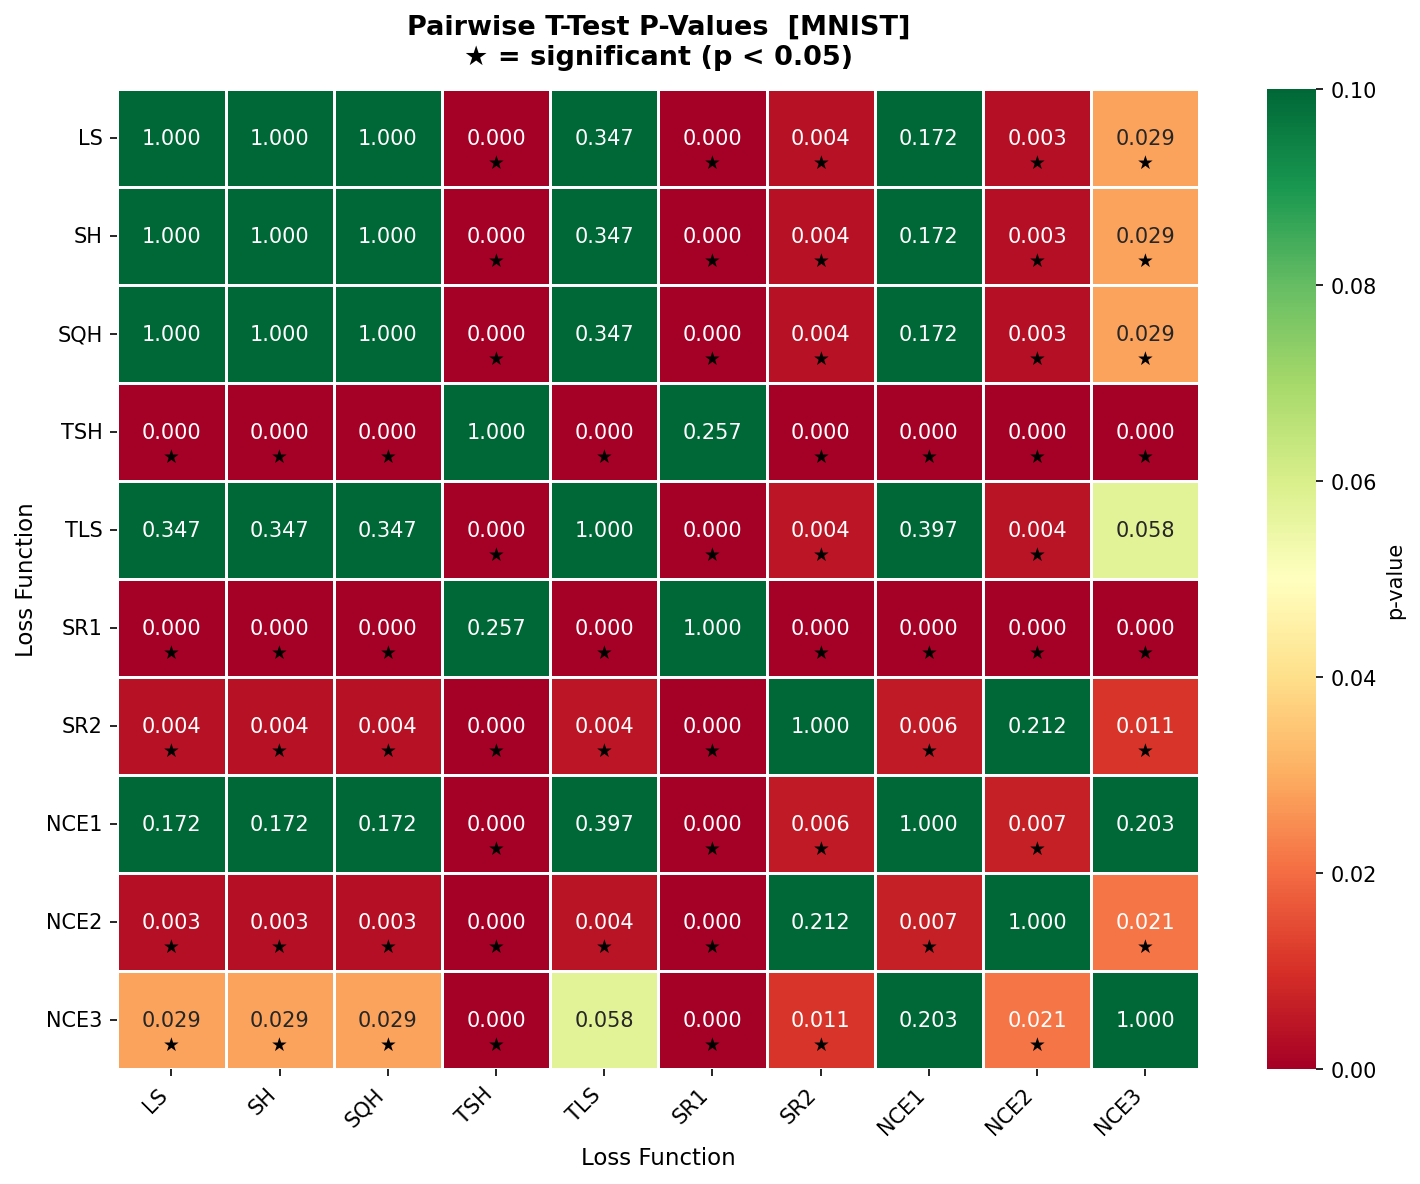

In [22]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load data (same as before) ─────────────────
EXCEL_FILE  = "test.xlsx"
SHEET_NAME  = 0
DATASET     = "mnist"

SHORT_NAMES = {
    "Least Squares"       : "LS",
    "Smooth Hinge"        : "SH",
    "Squared Hinge"       : "SQH",
    "Truncated SH"        : "TSH",
    "Truncated LS"        : "TLS",
    "Smoothed Ramp1"      : "SR1",
    "Smoothed Ramp2"      : "SR2",
    "nonconvex exp loss1" : "NCE1",
    "nonconvex exp loss2" : "NCE2",
    "nonconvex exp loss3" : "NCE3",
}

df = pd.read_excel(EXCEL_FILE, sheet_name=SHEET_NAME, header=0)
df.rename(columns={df.columns[0]: "Dataset Name", df.columns[1]: "Loss"}, inplace=True)
seed_cols = df.columns[2:].tolist()

df = df[df["Dataset Name"].str.strip().str.lower() == DATASET.lower()].copy()
df[seed_cols] = df[seed_cols].apply(pd.to_numeric, errors="coerce")
df["label"]   = df["Loss"].str.strip().map(SHORT_NAMES).fillna(df["Loss"].str.strip())
df = df.reset_index(drop=True)

# ── Pairwise t-test ────────────────────────────
labels  = df["label"].tolist()
n       = len(labels)
p_matrix = np.ones((n, n))   # fill with 1.0 by default

for i in range(n):
    for j in range(n):
        if i != j:
            a = df.loc[i, seed_cols].values.astype(float)
            b = df.loc[j, seed_cols].values.astype(float)
            # Only run test if at least one group has variance
            if np.std(a) == 0 and np.std(b) == 0:
                p_matrix[i, j] = 1.0   # both identical, no difference
            else:
                _, p_val = stats.ttest_ind(a, b)
                p_matrix[i, j] = p_val

p_df = pd.DataFrame(p_matrix, index=labels, columns=labels)

print("\nP-value matrix:")
print(p_df.round(4))

# ── Heatmap ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

heatmap = sns.heatmap(
    p_df,
    annot       = True,
    fmt         = ".3f",
    cmap        = "RdYlGn",     # red = significant, green = not significant
    vmin        = 0,
    vmax        = 0.1,
    linewidths  = 0.5,
    ax          = ax,
    cbar_kws    = {"label": "p-value"}
)

# Mark significant cells with a star
for i in range(n):
    for j in range(n):
        if i != j and p_matrix[i, j] < 0.05:
            ax.text(j + 0.5, i + 0.75, "★",
                    ha="center", va="center",
                    fontsize=9, color="black")

ax.set_title(f"Pairwise T-Test P-Values  [{DATASET.upper()}]\n★ = significant (p < 0.05)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Loss Function", fontsize=11)
ax.set_ylabel("Loss Function", fontsize=11)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
df_check = pd.read_excel('test.xlsx', sheet_name=0)
print(df_check.iloc[:, 0].unique())  

['magic_gamma_telescope' 'A9a' 'Run_or_walk_information' 'hepmass' 'susy']


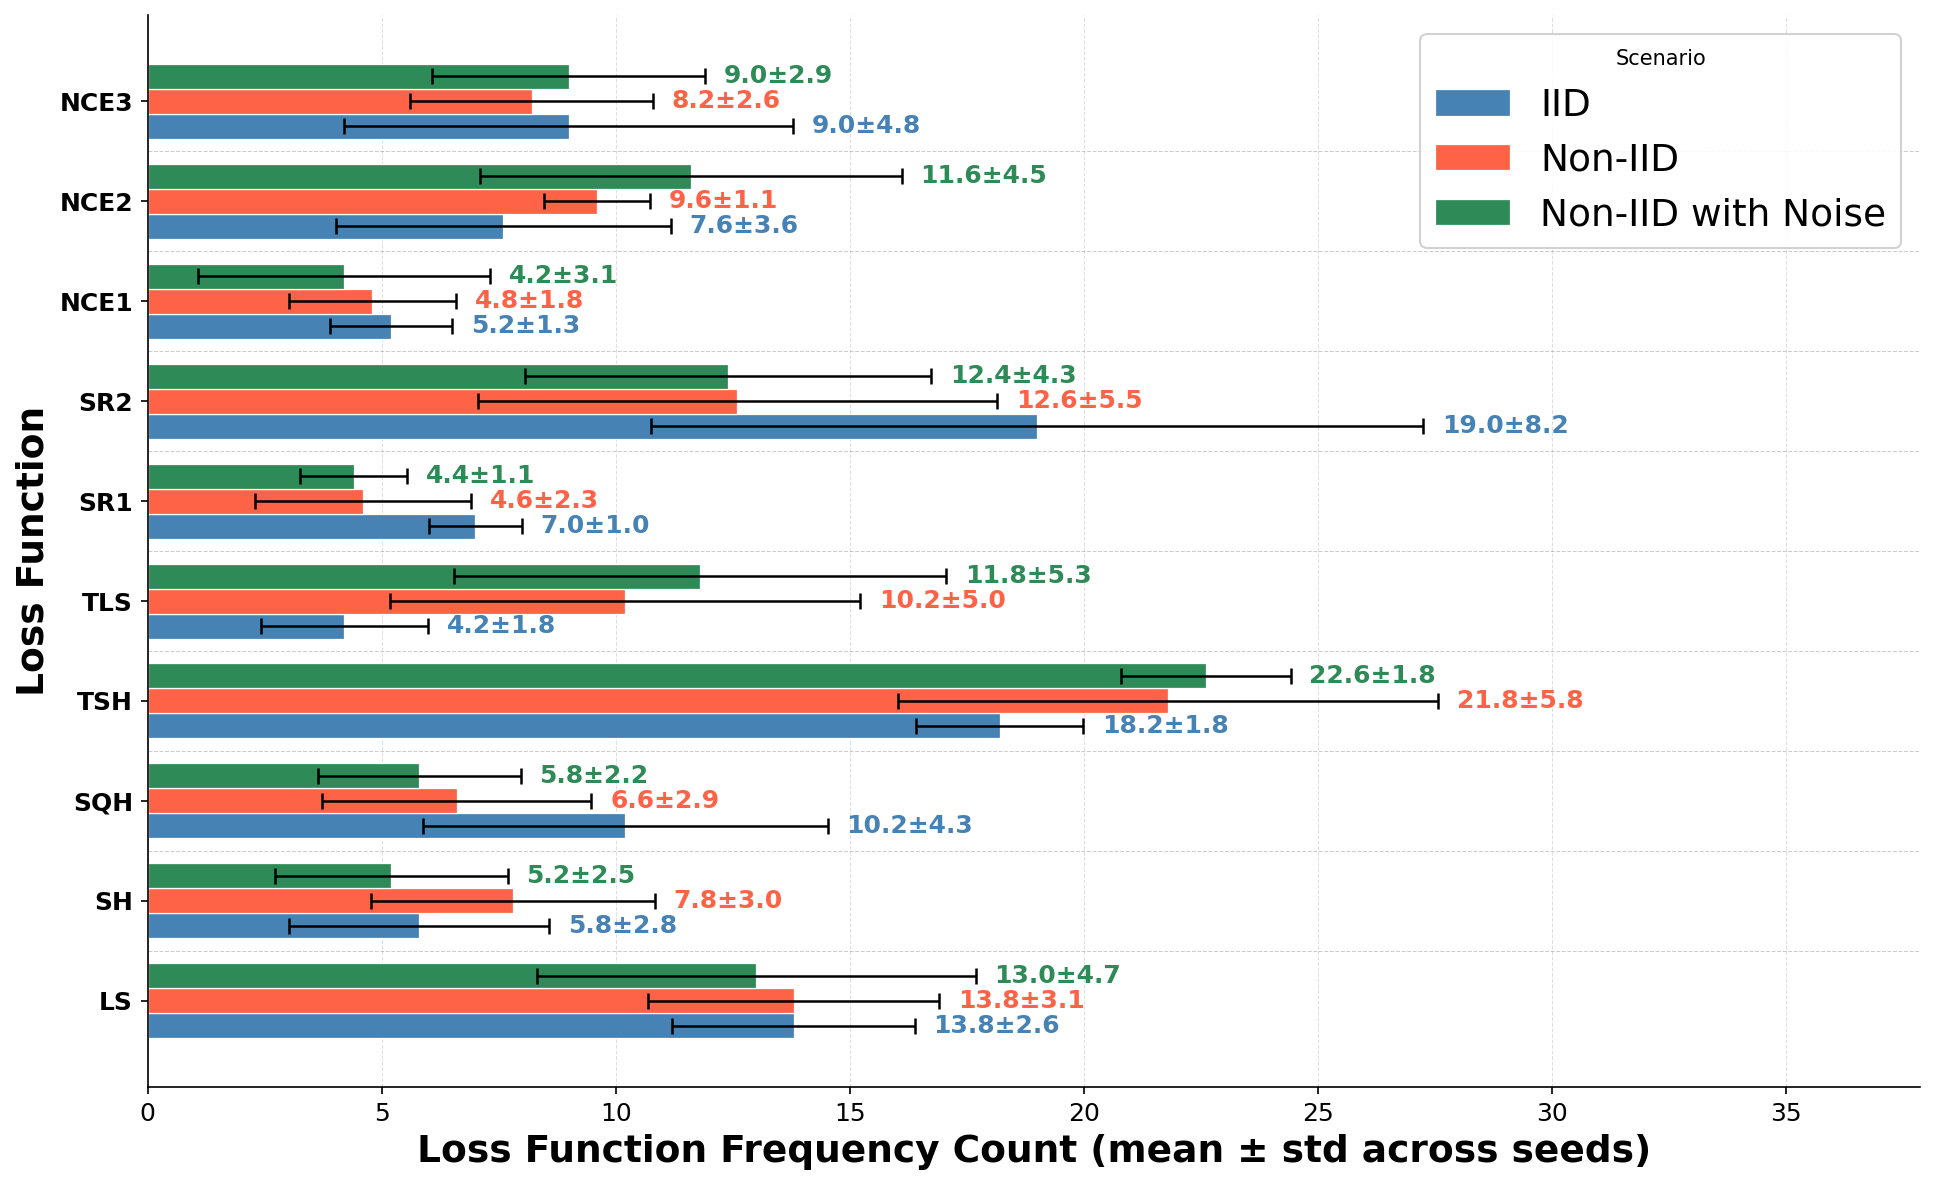

KeyError: 'A9a'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def export_to_excel(all_scenario_data, datasets, save_path="test_results.xlsx"):
    rows = {}
    for scenario_name in SCENARIOS.keys():
        df0 = all_scenario_data[datasets[0]][scenario_name]
        for _, row in df0.iterrows():
            label = row["label"]
            row_key = f"{label} | {scenario_name}"
            rows[row_key] = {}
            for dataset in datasets:
                df = all_scenario_data[dataset][scenario_name]
                match = df[df["label"] == label]
                if not match.empty:
                    m, s = match.iloc[0]["mean"], match.iloc[0]["std"]
                    rows[row_key][dataset.upper()] = f"{m:.1f}±{s:.1f}"

    result_df = pd.DataFrame(rows).T
    result_df.index.name = "Loss Function | Scenario"

    with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
        result_df.to_excel(writer, sheet_name="Results")

    print(f"Results saved → {save_path}")

# ─────────────────────────────────────────────
#  USER CONTROLS
# ─────────────────────────────────────────────
EXCEL_FILE  = "test.xlsx"
# After
DATASETS = ["magic_gamma_telescope", "A9a", "Run_or_walk_information",'hepmass', 'susy']

# Sheet names for each scenario — change to match your actual sheet names
SCENARIOS = {
    "IID"             : 0,   # sheet index or name e.g. "iid"
    "Non-IID"         : 1,
    "Non-IID with Noise" : 2,
}

# Colors for each scenario bar
SCENARIO_COLORS = {
    "IID"             : "steelblue",
    "Non-IID"         : "tomato",
    "Non-IID with Noise" : "seagreen",
}

BAR_HEIGHT       = 0.25       # thickness of each bar — reduce if bars overlap
ERROR_BAR_COLOR  = "black"
ERROR_BAR_CAP    = 4

TITLE_FONTSIZE   = 18
AXIS_LABEL_SIZE  = 18
TICK_LABEL_SIZE  = 12
VALUE_LABEL_SIZE = 12
FONT_FAMILY      = "DejaVu Sans"
FONT_WEIGHT      = "bold"

FIG_WIDTH        = 13
FIG_HEIGHT       = 8
DPI              = 150
SAVE_PATH        = None    # e.g. "plot.png"
# ─────────────────────────────────────────────

SHORT_NAMES = {
    "Least Squares"       : "LS",
    "Smooth Hinge"        : "SH",
    "Squared Hinge"       : "SQH",
    "Truncated SH"        : "TSH",
    "Truncated LS"        : "TLS",
    "Smoothed Ramp1"      : "SR1",
    "Smoothed Ramp2"      : "SR2",
    "nonconvex exp loss1" : "NCE1",
    "nonconvex exp loss2" : "NCE2",
    "nonconvex exp loss3" : "NCE3",
}

# ── Load all sheets ───────────────────────────
def load_scenario(excel_file, sheet, dataset):
    df = pd.read_excel(excel_file, sheet_name=sheet, header=0)
    df.rename(columns={df.columns[0]: "Dataset Name", df.columns[1]: "Loss"}, inplace=True)
    seed_cols = df.columns[2:].tolist()
    df = df[df["Dataset Name"].str.strip().str.lower() == dataset.lower()].copy()
    if df.empty:
        raise ValueError(f"No rows for dataset='{dataset}' in sheet='{sheet}'")
    df[seed_cols] = df[seed_cols].apply(pd.to_numeric, errors="coerce")
    df["mean"]  = df[seed_cols].mean(axis=1)
    df["std"]   = df[seed_cols].std(axis=1)
    df["label"] = df["Loss"].str.strip().map(SHORT_NAMES).fillna(df["Loss"].str.strip())
    df = df.reset_index(drop=True)
    return df

scenario_data_all = {
    name: load_scenario(EXCEL_FILE, sheet, "mnist")  # placeholder, overridden below
    for name, sheet in SCENARIOS.items()
}

def load_scenario_all(excel_file, sheet):
    df = pd.read_excel(excel_file, sheet_name=sheet, header=0)
    df.rename(columns={df.columns[0]: "Dataset Name", df.columns[1]: "Loss"}, inplace=True)
    return df

# Load raw sheets once
raw_sheets = {name: load_scenario_all(EXCEL_FILE, sheet) for name, sheet in SCENARIOS.items()}

for DATASET in DATASETS:
    scenario_data = {}
    for name, sheet in SCENARIOS.items():
        df = raw_sheets[name].copy()
        seed_cols = df.columns[2:].tolist()
        df = df[df["Dataset Name"].str.strip().str.lower() == DATASET.lower()].copy()
        if df.empty:
            raise ValueError(f"No rows for dataset='{DATASET}' in sheet='{sheet}'")
        df[seed_cols] = df[seed_cols].apply(pd.to_numeric, errors="coerce")
        df["mean"]  = df[seed_cols].mean(axis=1)
        df["std"]   = df[seed_cols].std(axis=1)
        df["label"] = df["Loss"].str.strip().map(SHORT_NAMES).fillna(df["Loss"].str.strip())
        df = df.reset_index(drop=True)
        scenario_data[name] = df

    loss_labels = scenario_data[list(SCENARIOS.keys())[0]]["label"].tolist()
    n_losses    = len(loss_labels)
    n_scenarios = len(SCENARIOS)

    # ── Plot ──────────────────────────────────────
    plt.rcParams.update({"font.family": FONT_FAMILY})

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)

    total_height = BAR_HEIGHT * n_scenarios
    offsets      = np.linspace(-total_height / 2 + BAR_HEIGHT / 2,
                                total_height / 2 - BAR_HEIGHT / 2,
                                n_scenarios)

    y_base = np.arange(n_losses)

    for idx, (scenario_name, offset) in enumerate(zip(SCENARIOS.keys(), offsets)):
        df       = scenario_data[scenario_name]
        y_pos    = y_base + offset
        means    = df["mean"].values
        stds     = df["std"].values
        color    = SCENARIO_COLORS[scenario_name]

        ax.barh(
            y_pos, means, height=BAR_HEIGHT, color=color, edgecolor="white",
            linewidth=0.6, xerr=stds,
            error_kw=dict(ecolor=ERROR_BAR_COLOR, capsize=ERROR_BAR_CAP,
                          elinewidth=1.2, capthick=1.2),
            label=scenario_name, zorder=2,
        )

        for i, (m, s) in enumerate(zip(means, stds)):
            ax.text(m + s + 0.4, y_pos[i], f"{m:.1f}±{s:.1f}", va="center", ha="left",
                    fontsize=VALUE_LABEL_SIZE, color=color, fontweight=FONT_WEIGHT)

    ax.set_yticks(y_base)
    ax.set_yticklabels(loss_labels, fontsize=TICK_LABEL_SIZE, fontweight=FONT_WEIGHT)

    for y in y_base[:-1]:
        ax.axhline(y + 0.5, color="grey", linewidth=0.5, linestyle="--", alpha=0.4)

    ax.set_xlabel("Loss Function Frequency Count (mean ± std across seeds)", fontsize=AXIS_LABEL_SIZE, fontweight=FONT_WEIGHT)
    ax.set_ylabel("Loss Function", fontsize=AXIS_LABEL_SIZE, fontweight=FONT_WEIGHT)
    # ax.set_title(f"Error Rate per Loss Function — {DATASET.upper()}\n",
    #              fontsize=TITLE_FONTSIZE, fontweight="bold", pad=14)

    ax.tick_params(axis="x", labelsize=TICK_LABEL_SIZE)

    max_val = max(df["mean"].max() + df["std"].max() for df in scenario_data.values())
    ax.set_xlim(0, max_val + 10)

    ax.legend(title="Scenario", fontsize=18, title_fontsize=10,
              loc="upper right", framealpha=0.9)

    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    plt.tight_layout()

    # if SAVE_PATH:
    #     save_name = SAVE_PATH.replace(".", f"_{DATASET}.")
    #     plt.savefig(save_name, bbox_inches="tight", facecolor="white")
    #     print(f"Saved → {save_name}")

    plt.show()


════════════════════════════════════════════════════════════
TEST 1: One-sample t-test (each loss vs 0)
════════════════════════════════════════════════════════════

── IID ──
  LS      t=+0.000  p=1.0000    not significant
  SH      t=+0.000  p=1.0000    not significant
  SQH     t=+0.000  p=1.0000    not significant
  TSH     t=+12.578  p=0.0002  ★ SIGNIFICANT
  TLS     t=+3.515  p=0.0246  ★ SIGNIFICANT
  SR1     t=+13.138  p=0.0002  ★ SIGNIFICANT
  SR2     t=+9.655  p=0.0006  ★ SIGNIFICANT
  NCE1    t=+13.898  p=0.0002  ★ SIGNIFICANT
  NCE2    t=+5.071  p=0.0071  ★ SIGNIFICANT
  NCE3    t=+4.118  p=0.0146  ★ SIGNIFICANT

── Non-IID ──
  LS      t=+0.000  p=1.0000    not significant
  SH      t=+0.000  p=1.0000    not significant
  SQH     t=+0.000  p=1.0000    not significant
  TSH     t=+36.515  p=0.0000  ★ SIGNIFICANT
  TLS     t=+4.238  p=0.0133  ★ SIGNIFICANT
  SR1     t=+14.655  p=0.0001  ★ SIGNIFICANT
  SR2     t=+8.222  p=0.0012  ★ SIGNIFICANT
  NCE1    t=+5.976  p=0.0039  ★

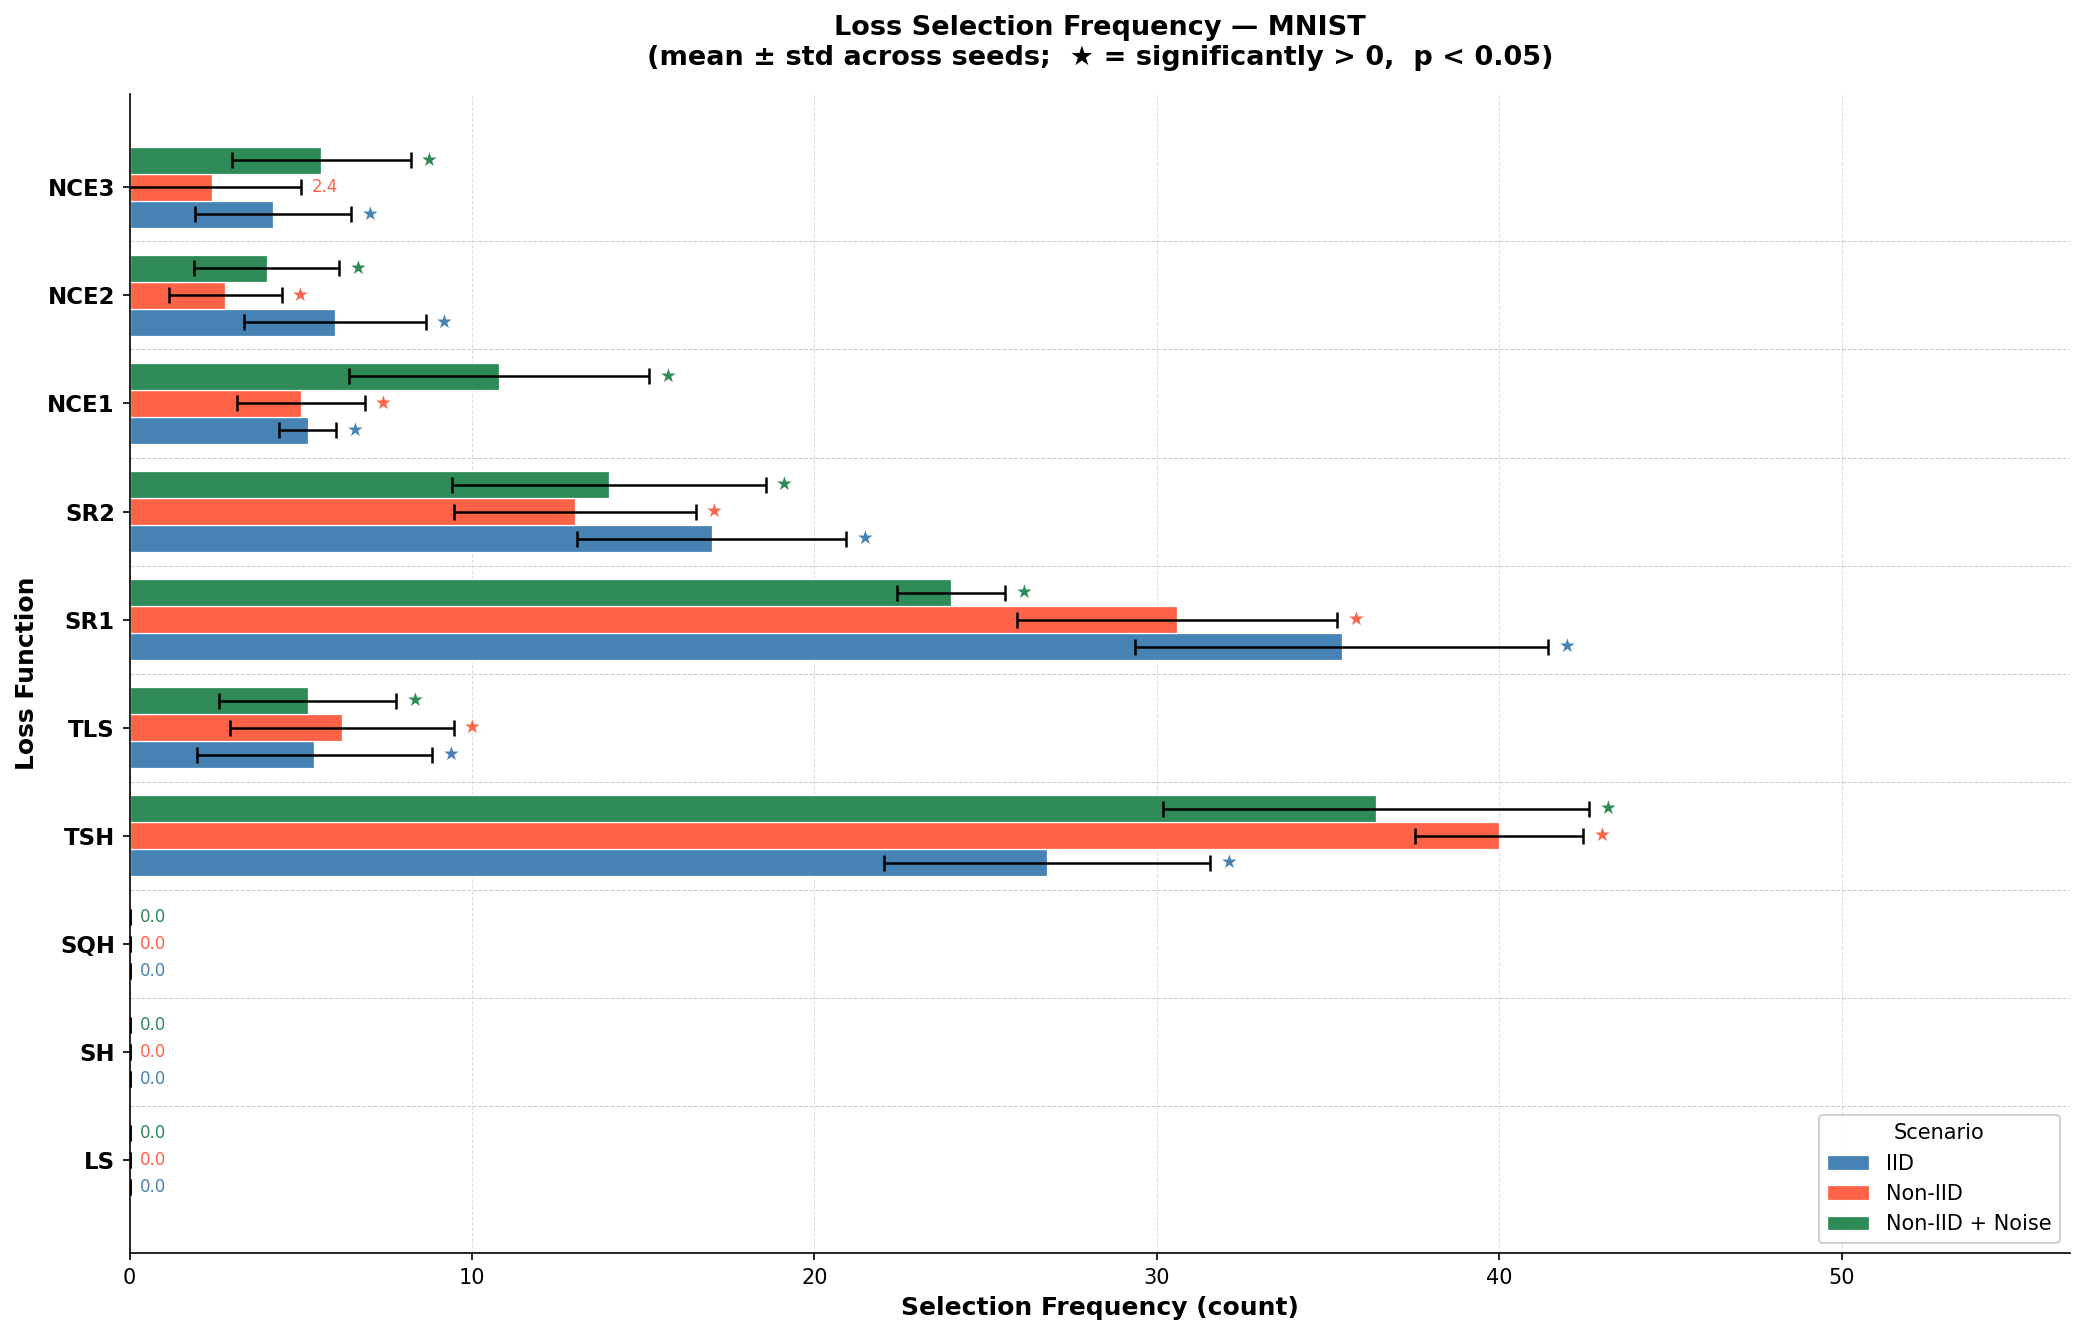

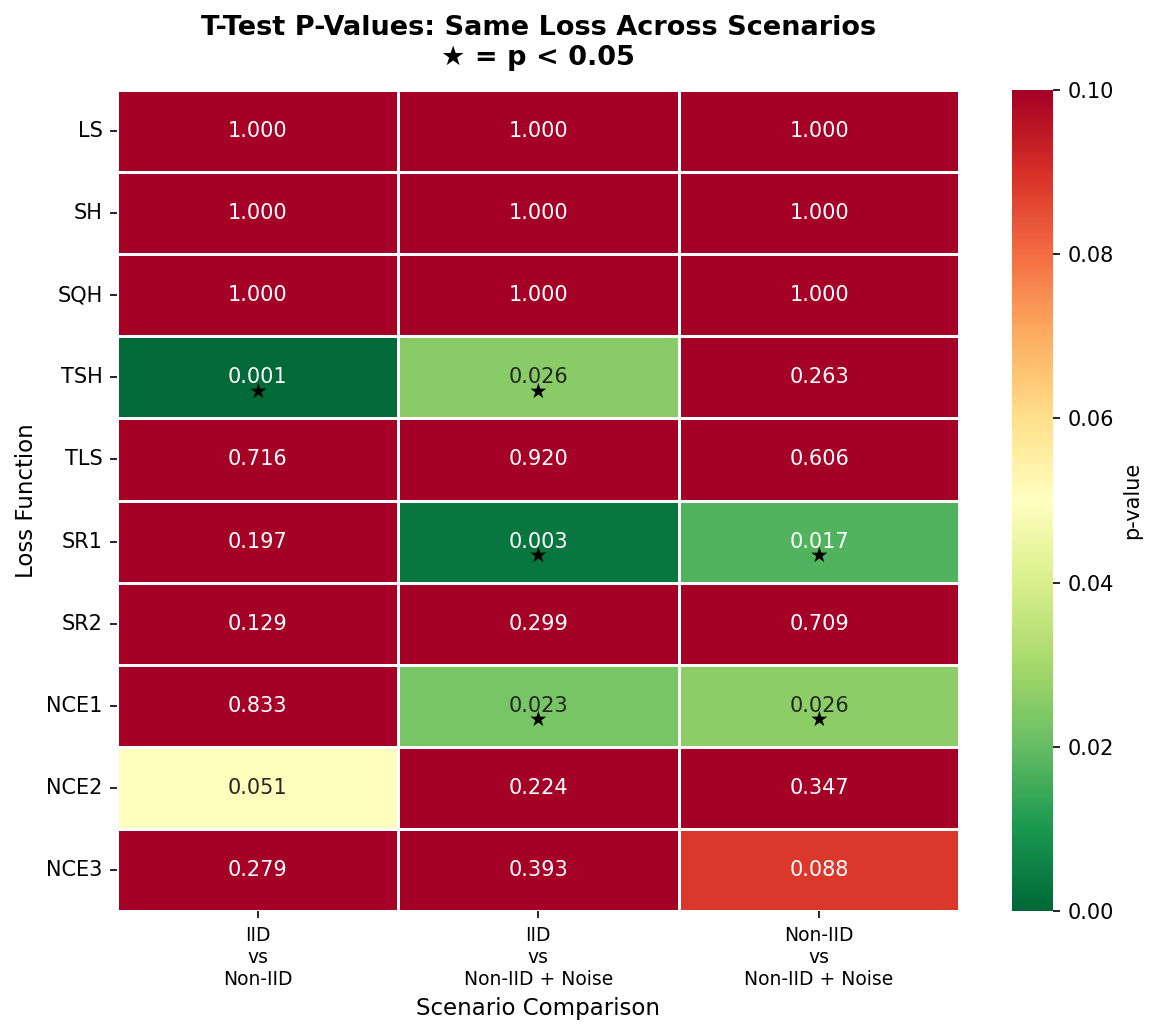

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from scipy import stats
from itertools import combinations

# ─────────────────────────────────────────────
#  USER CONTROLS
# ─────────────────────────────────────────────
EXCEL_FILE  = "test.xlsx"
DATASET     = "mnist"

SCENARIOS = {
    "IID"             : 0,
    "Non-IID"         : 1,
    "Non-IID + Noise" : 2,
}

SCENARIO_COLORS = {
    "IID"             : "steelblue",
    "Non-IID"         : "tomato",
    "Non-IID + Noise" : "seagreen",
}

SHORT_NAMES = {
    "Least Squares"       : "LS",
    "Smooth Hinge"        : "SH",
    "Squared Hinge"       : "SQH",
    "Truncated SH"        : "TSH",
    "Truncated LS"        : "TLS",
    "Smoothed Ramp1"      : "SR1",
    "Smoothed Ramp2"      : "SR2",
    "nonconvex exp loss1" : "NCE1",
    "nonconvex exp loss2" : "NCE2",
    "nonconvex exp loss3" : "NCE3",
}

ALPHA       = 0.05     # significance threshold
BAR_HEIGHT  = 0.25
FIG_WIDTH   = 14
FIG_HEIGHT  = 9
DPI         = 150
SAVE_PATH   = None
# ─────────────────────────────────────────────

def load_scenario(excel_file, sheet, dataset):
    df = pd.read_excel(excel_file, sheet_name=sheet, header=0)
    df.rename(columns={df.columns[0]: "Dataset Name", df.columns[1]: "Loss"}, inplace=True)
    seed_cols = df.columns[2:].tolist()
    df = df[df["Dataset Name"].str.strip().str.lower() == dataset.lower()].copy()
    df[seed_cols] = df[seed_cols].apply(pd.to_numeric, errors="coerce")
    df["mean"]    = df[seed_cols].mean(axis=1)
    df["std"]     = df[seed_cols].std(axis=1)
    df["label"]   = df["Loss"].str.strip().map(SHORT_NAMES).fillna(df["Loss"].str.strip())
    df["values"]  = df[seed_cols].values.tolist()   # keep raw seed values
    return df.reset_index(drop=True)

scenario_data = {
    name: load_scenario(EXCEL_FILE, sheet, DATASET)
    for name, sheet in SCENARIOS.items()
}

loss_labels = scenario_data[list(SCENARIOS.keys())[0]]["label"].tolist()
n_losses    = len(loss_labels)
n_scenarios = len(SCENARIOS)

# ═══════════════════════════════════════════════════
#  TEST 1 — One-sample t-test: each loss vs zero
#  "Is this loss selected significantly more than 0?"
# ═══════════════════════════════════════════════════
print("\n" + "═"*60)
print("TEST 1: One-sample t-test (each loss vs 0)")
print("═"*60)

sig_vs_zero = {}   # {(scenario, loss_label): True/False}

for scenario, df in scenario_data.items():
    print(f"\n── {scenario} ──")
    for _, row in df.iterrows():
        vals = np.array(row["values"], dtype=float)
        if np.std(vals) == 0:
            p = 1.0   # all zeros → no difference from 0
            t = 0.0
        else:
            t, p = stats.ttest_1samp(vals, popmean=0)
        sig = p < ALPHA
        sig_vs_zero[(scenario, row["label"])] = sig
        marker = "★ SIGNIFICANT" if sig else "  not significant"
        print(f"  {row['label']:<6}  t={t:+.3f}  p={p:.4f}  {marker}")

# ═══════════════════════════════════════════════════
#  TEST 2 — Pairwise t-test between losses per scenario
# ═══════════════════════════════════════════════════
print("\n" + "═"*60)
print("TEST 2: Pairwise t-test between losses within each scenario")
print("═"*60)

for scenario, df in scenario_data.items():
    print(f"\n── {scenario} ──")
    labels_list = df["label"].tolist()
    for (i, j) in combinations(range(len(df)), 2):
        a = np.array(df.loc[i, "values"], dtype=float)
        b = np.array(df.loc[j, "values"], dtype=float)
        if np.std(a) == 0 and np.std(b) == 0:
            p = 1.0; t = 0.0
        else:
            t, p = stats.ttest_ind(a, b)
        if p < ALPHA:
            print(f"  ★ {labels_list[i]} vs {labels_list[j]}: "
                  f"t={t:+.3f}, p={p:.4f}  ← significant")

# ═══════════════════════════════════════════════════
#  TEST 3 — Same loss across scenarios
# ═══════════════════════════════════════════════════
print("\n" + "═"*60)
print("TEST 3: Same loss compared across scenarios")
print("═"*60)

scenario_names = list(SCENARIOS.keys())
for loss_label in loss_labels:
    print(f"\n── {loss_label} ──")
    for (s1, s2) in combinations(scenario_names, 2):
        a = np.array(scenario_data[s1].loc[
                scenario_data[s1]["label"] == loss_label, "values"
            ].values[0], dtype=float)
        b = np.array(scenario_data[s2].loc[
                scenario_data[s2]["label"] == loss_label, "values"
            ].values[0], dtype=float)
        if np.std(a) == 0 and np.std(b) == 0:
            p = 1.0; t = 0.0
        else:
            t, p = stats.ttest_ind(a, b)
        marker = "★ significant" if p < ALPHA else "not significant"
        print(f"  {s1} vs {s2}: t={t:+.3f}, p={p:.4f}  {marker}")

# ═══════════════════════════════════════════════════
#  PLOT — Bar chart with significance markers
# ═══════════════════════════════════════════════════
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)

y_base  = np.arange(n_losses)
offsets = np.linspace(-BAR_HEIGHT * n_scenarios / 2 + BAR_HEIGHT / 2,
                       BAR_HEIGHT * n_scenarios / 2 - BAR_HEIGHT / 2,
                       n_scenarios)

bar_positions = {}   # store for significance annotation

for idx, (scenario_name, offset) in enumerate(zip(SCENARIOS.keys(), offsets)):
    df    = scenario_data[scenario_name]
    y_pos = y_base + offset
    means = df["mean"].values
    stds  = df["std"].values
    color = SCENARIO_COLORS[scenario_name]

    ax.barh(
        y_pos, means,
        height    = BAR_HEIGHT,
        color     = color,
        edgecolor = "white",
        linewidth = 0.6,
        xerr      = stds,
        error_kw  = dict(ecolor="black", capsize=4, elinewidth=1.2, capthick=1.2),
        label     = scenario_name,
        zorder    = 2,
    )

    bar_positions[scenario_name] = y_pos.copy()

    # Add ★ above bars that are significant vs zero
    for i, (m, s, label) in enumerate(zip(means, stds, df["label"])):
        if sig_vs_zero.get((scenario_name, label), False):
            ax.text(m + s + 0.3, y_pos[i], "★",
                    va="center", ha="left",
                    fontsize=9, color=color, fontweight="bold")
        else:
            ax.text(m + s + 0.3, y_pos[i], f"{m:.1f}",
                    va="center", ha="left",
                    fontsize=8, color=color)

# Dividers between loss groups
for y in y_base[:-1]:
    ax.axhline(y + 0.5, color="grey", linewidth=0.5, linestyle="--", alpha=0.4)

ax.set_yticks(y_base)
ax.set_yticklabels(loss_labels, fontsize=11, fontweight="bold")

max_val = max(df["mean"].max() + df["std"].max() for df in scenario_data.values())
ax.set_xlim(0, max_val + 12)

ax.set_xlabel("Selection Frequency (count)", fontsize=12, fontweight="bold")
ax.set_ylabel("Loss Function",               fontsize=12, fontweight="bold")
ax.set_title(
    f"Loss Selection Frequency — {DATASET.upper()}\n"
    f"(mean ± std across seeds;  ★ = significantly > 0,  p < {ALPHA})",
    fontsize=13, fontweight="bold", pad=14
)

ax.legend(title="Scenario", fontsize=10, title_fontsize=10,
          loc="lower right", framealpha=0.9)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()
if SAVE_PATH:
    plt.savefig(SAVE_PATH, bbox_inches="tight", facecolor="white")
plt.show()

# ═══════════════════════════════════════════════════
#  HEATMAP — p-values for same loss across scenarios
# ═══════════════════════════════════════════════════
p_across = np.ones((n_losses, n_scenarios * (n_scenarios - 1) // 2))
col_labels = []
col_idx = 0

for (s1, s2) in combinations(scenario_names, 2):
    col_labels.append(f"{s1}\nvs\n{s2}")
    for li, loss_label in enumerate(loss_labels):
        a = np.array(scenario_data[s1].loc[
                scenario_data[s1]["label"] == loss_label, "values"
            ].values[0], dtype=float)
        b = np.array(scenario_data[s2].loc[
                scenario_data[s2]["label"] == loss_label, "values"
            ].values[0], dtype=float)
        if np.std(a) == 0 and np.std(b) == 0:
            p_across[li, col_idx] = 1.0
        else:
            _, p_across[li, col_idx] = stats.ttest_ind(a, b)
    col_idx += 1

p_heat = pd.DataFrame(p_across, index=loss_labels, columns=col_labels)

fig2, ax2 = plt.subplots(figsize=(8, 7), dpi=DPI)
sns.heatmap(
    p_heat, annot=True, fmt=".3f",
    cmap="RdYlGn_r",   # red = significant
    vmin=0, vmax=0.1,
    linewidths=0.5,
    ax=ax2,
    cbar_kws={"label": "p-value"}
)

# Star significant cells
for i in range(len(loss_labels)):
    for j in range(p_across.shape[1]):
        if p_across[i, j] < ALPHA:
            ax2.text(j + 0.5, i + 0.75, "★",
                     ha="center", fontsize=10, color="black")

ax2.set_title(f"T-Test P-Values: Same Loss Across Scenarios\n★ = p < {ALPHA}",
              fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Scenario Comparison", fontsize=11)
ax2.set_ylabel("Loss Function",        fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

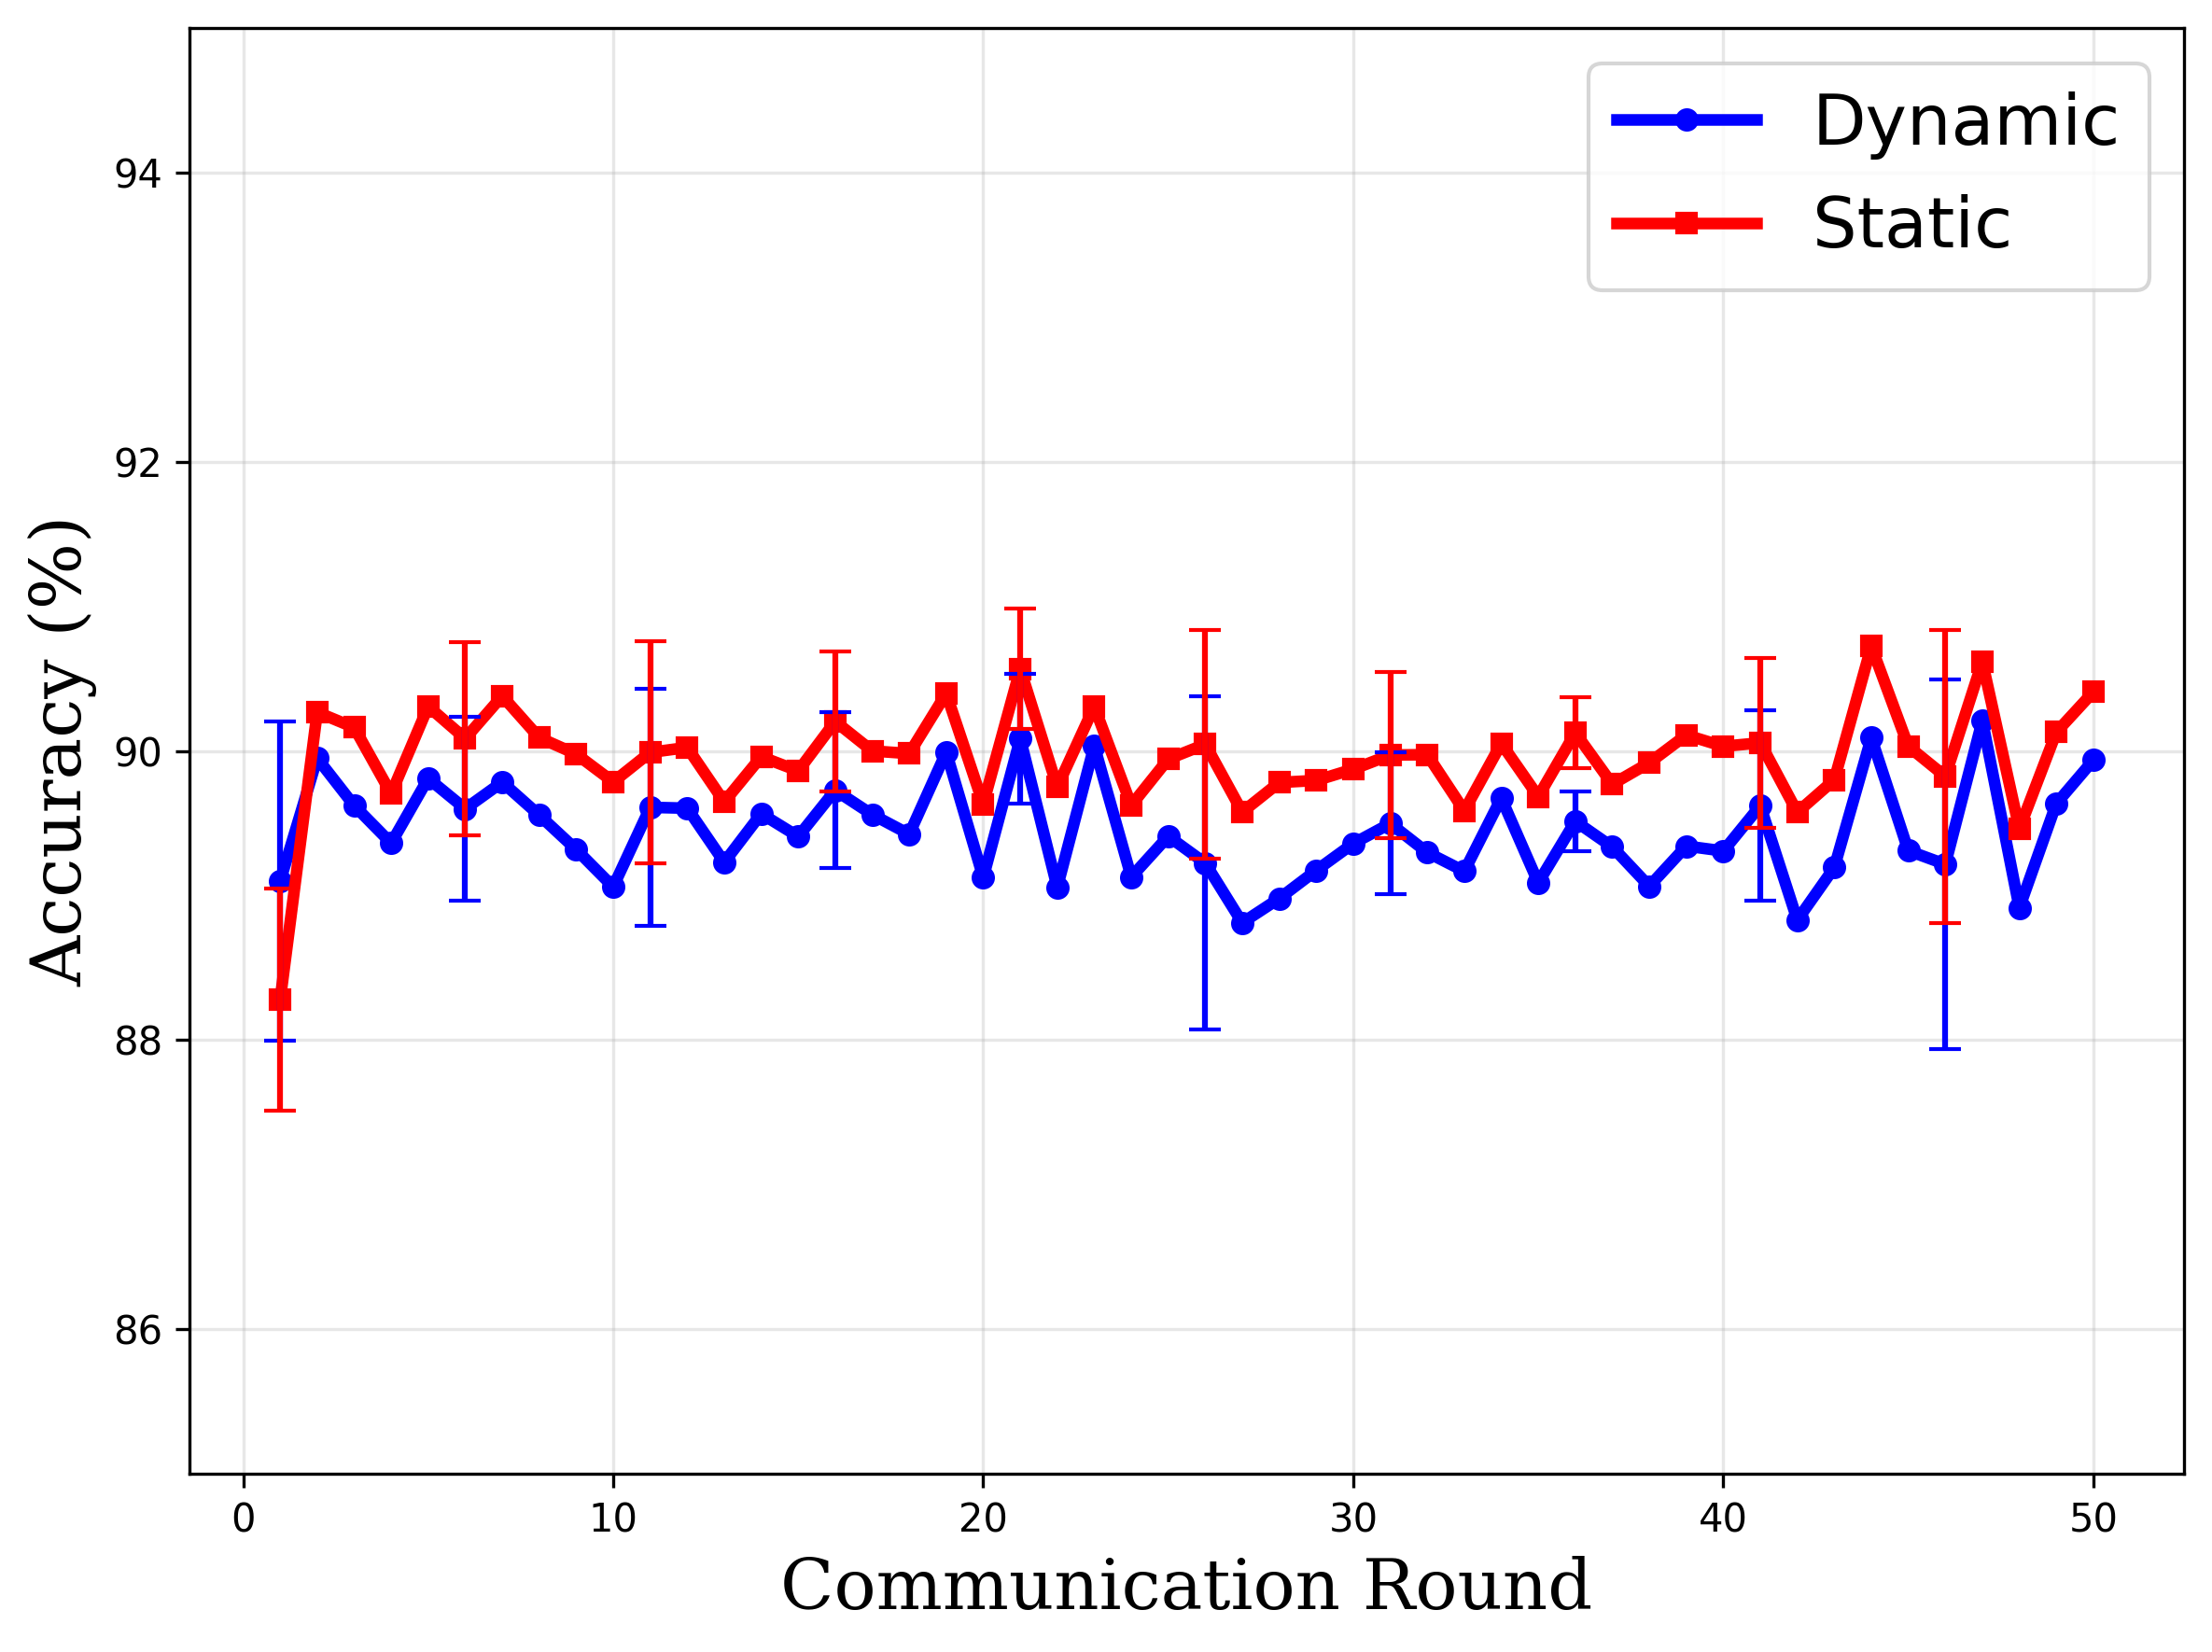

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# USER SETTINGS (EDIT FREELY)
# ==========================================

excel_path = "test.xlsx"

errorbar_interval = 5     # show error bar every k rounds (5 or 10 recommended)

fig_width = 8
fig_height = 6
dpi_value = 300

line_width = 3
marker_size = 5
cap_size = 4

dynamic_color = "blue"
static_color = "red"

font_family = "serif"

# ==========================================
# READ EXCEL
# ==========================================

df = pd.read_excel(excel_path)
df.columns = df.columns.astype(str)

# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

dynamic_cols = [col for col in numeric_df.columns if "dynamic" in col.lower()]
static_cols = [col for col in numeric_df.columns if "static" in col.lower()]

# Compute mean & std
dynamic_mean = df[dynamic_cols].mean(axis=1)
dynamic_std = df[dynamic_cols].std(axis=1)

static_mean = df[static_cols].mean(axis=1)
static_std = df[static_cols].std(axis=1)

rounds = df["Round"]

# ==========================================
# DETERMINE Y-AXIS LIMITS
# ==========================================

global_min = numeric_df.min().min()
# y_lower = global_min - 10
y_lower = 85
y_upper = 95

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(fig_width, fig_height), dpi=dpi_value)

# Plot lines (without error bars)
plt.plot(rounds, dynamic_mean,
         label="Dynamic",
         color=dynamic_color,
         linewidth=line_width,
         marker="o",
         markersize=marker_size)

plt.plot(rounds, static_mean,
         label="Static",
         color=static_color,
         linewidth=line_width,
         marker="s",
         markersize=marker_size)

# Add error bars only every k rounds
interval_indices = np.arange(0, len(rounds), errorbar_interval)

plt.errorbar(rounds.iloc[interval_indices],
             dynamic_mean.iloc[interval_indices],
             yerr=dynamic_std.iloc[interval_indices],
             fmt='none',
             ecolor=dynamic_color,
             capsize=cap_size)

plt.errorbar(rounds.iloc[interval_indices],
             static_mean.iloc[interval_indices],
             yerr=static_std.iloc[interval_indices],
             fmt='none',
             ecolor=static_color,
             capsize=cap_size)

plt.ylim(y_lower, y_upper)

plt.xlabel("Communication Round", fontfamily=font_family, fontsize=18)
plt.ylabel("Accuracy (%)", fontfamily=font_family, fontsize=18)

plt.legend(fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Accuracy Error bar

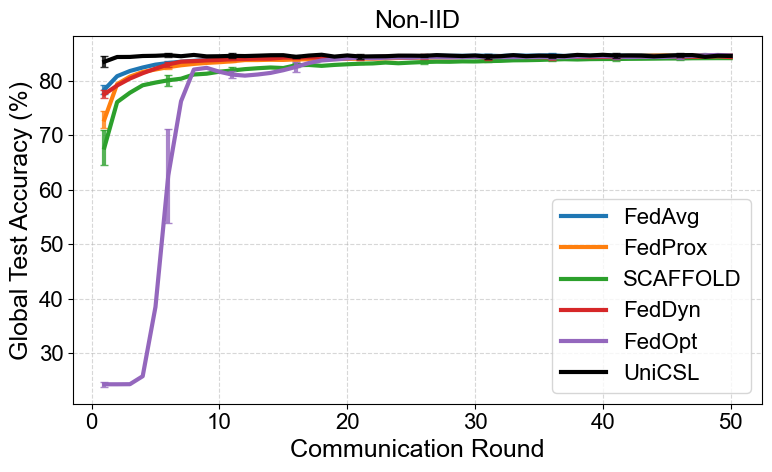

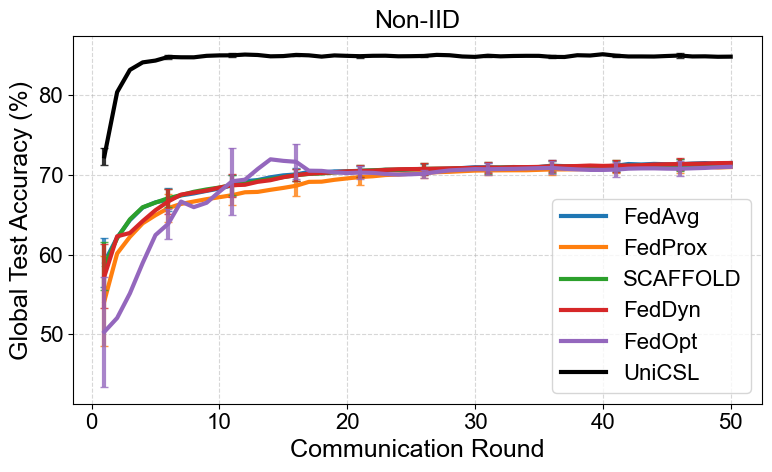

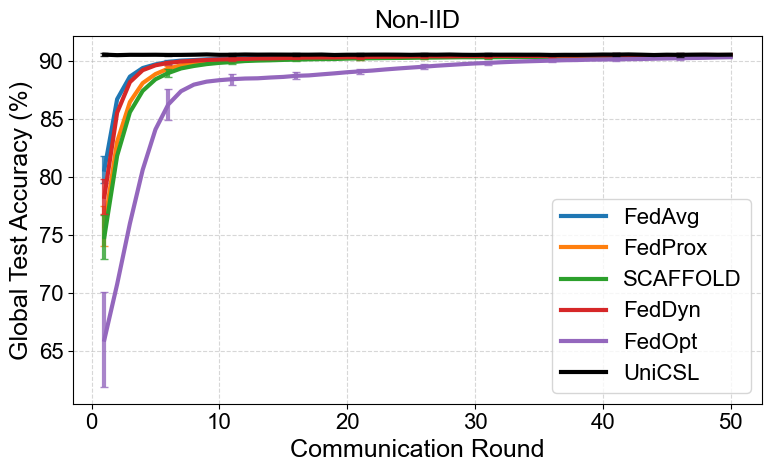

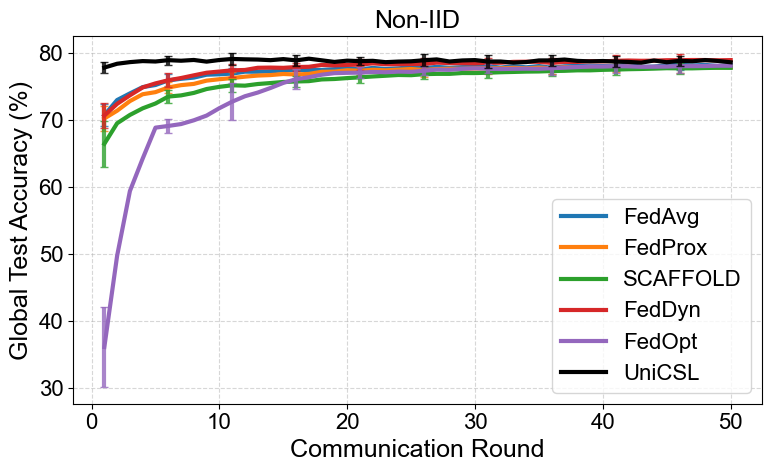

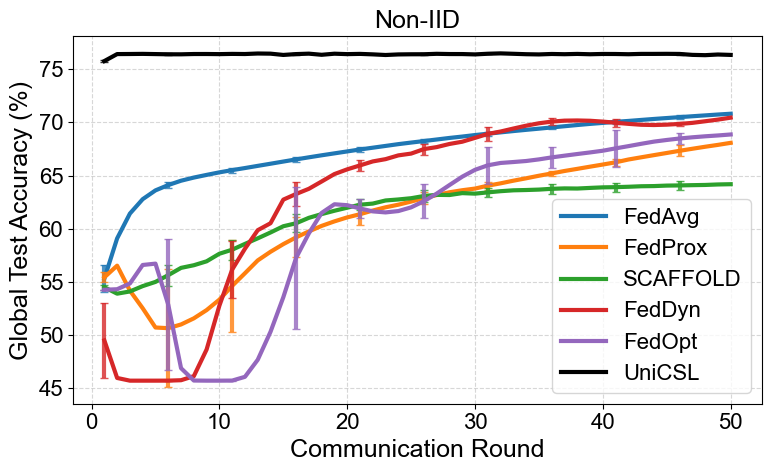

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 🔧 USER SETTINGS (customize freely)
# ─────────────────────────────────────────────
excel_path = "test.xlsx"   # path to your excel
algorithms = ["fedavg", "fedprox", "scaffold", "feddyn", "fedopt", "unicsl"]
seeds = [1, 12, 123, 1234, 42]
datasets = ["A9a", "Run_or_walk_information", "hepmass","magic_gamma_telescope","susy"] 
error_interval = 5   # show error bars every N rounds (e.g., 5 or 10)

# font settings
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 16
})

# optional color map (customize)
color_map = {
    "fedavg": "#1f77b4",
    "fedprox": "#ff7f0e",
    "scaffold": "#2ca02c",
    "feddyn": "#d62728",
    "fedopt": "#9467bd",
    "unicsl": "#000000",
}

display_names = {
    "fedavg":  "FedAvg",
    "fedprox": "FedProx",
    "scaffold":"SCAFFOLD",
    "feddyn":  "FedDyn",
    "fedopt":  "FedOpt",
    "unicsl":  "UniCSL",
}

df = pd.read_excel(excel_path)

for dataset in datasets:
    df_ds = df[df["Dataset"].str.strip().str.lower() == dataset.lower()].copy().reset_index(drop=True)
    if df_ds.empty:
        print(f"[WARN] No data found for dataset: {dataset}")
        continue

    rounds = df_ds["Round"].values

    algo_mean = {}
    algo_std  = {}

    for algo in algorithms:
        cols = [f"{algo}_{s}" for s in seeds]
        missing = [c for c in cols if c not in df_ds.columns]
        if missing:
            print(f"[WARN] Missing columns for {algo} in {dataset}: {missing}")
            continue

        values = df_ds[cols].values
        algo_mean[algo] = np.mean(values, axis=1)
        algo_std[algo]  = np.std(values, axis=1)

    # ── Plot ──────────────────────────────────
    plt.figure(figsize=(8, 5))

    for algo in algo_mean:
        mean    = algo_mean[algo]
        std     = algo_std[algo]
        err_idx = np.arange(0, len(rounds), error_interval)

        plt.plot(
            rounds, mean,
            label=display_names.get(algo, algo.upper()),
            color=color_map.get(algo, None),
            linewidth=3
        )
        plt.errorbar(
            rounds[err_idx], mean[err_idx], yerr=std[err_idx],
            fmt='none', ecolor=color_map.get(algo, None),
            elinewidth=3, capsize=3, alpha=0.8
        )

    plt.xlabel("Communication Round", fontsize=18)
    plt.ylabel("Global Test Accuracy (%)", fontsize=18)
    plt.title(f'Non-IID', fontsize=18)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Paired t-test

In [31]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel

def summarize_with_ttest(excel_path, sheet_name=0, unicsl_col="UniCSL_Static"):
    df = pd.read_excel(excel_path, sheet_name=sheet_name)

    algorithms = [col for col in df.columns if col not in ["Dataset", "Seed"]]

    final_rows = []

    for dataset, group in df.groupby("Dataset"):

        row = {"Dataset": dataset}

        # UniCSL values
        unicsl_vals = group[unicsl_col].values
        uni_mean = np.mean(unicsl_vals)
        uni_std  = np.std(unicsl_vals, ddof=1)   # ✅ FIXED

        row[unicsl_col] = f"{uni_mean:.2f} ± {uni_std:.2f}"

        for algo in algorithms:
            if algo == unicsl_col:
                continue

            vals = group[algo].values

            mean = np.mean(vals)
            std  = np.std(vals, ddof=1)

            t_stat, p_val = ttest_rel(vals, unicsl_vals)

            # 👉 ADD HERE
            p_text = "<0.001" if p_val < 0.001 else f"{p_val:.4f}"

            cell_text = (
                f"{mean:.2f} ± {std:.2f}\n"
                f"({t_stat:.2f}, {p_text})"
            )

            row[algo] = cell_text

        final_rows.append(row)

    cols = ["Dataset"] + [c for c in algorithms if c != unicsl_col] + [unicsl_col]

    final_df = pd.DataFrame(final_rows)[cols]

    return final_df

excel_path = "test.xlsx"

final_df = summarize_with_ttest(excel_path)

print(final_df)

# save to Excel
final_df.to_excel("test_output.xlsx", index=False)

         Dataset                          FedAvg  \
0       CIFAR 10  75.80 ± 0.37\n(-48.81, <0.001)   
1  Fashion MNIST  78.73 ± 0.23\n(-15.46, <0.001)   
2          MNIST    90.28 ± 0.21\n(5.72, 0.0046)   

                          FedProx                        SCAFFOLD  \
0  75.77 ± 0.37\n(-49.44, <0.001)  77.25 ± 0.20\n(-35.83, <0.001)   
1  78.60 ± 0.20\n(-18.89, <0.001)  73.13 ± 0.58\n(-32.66, <0.001)   
2    90.18 ± 0.20\n(4.15, 0.0142)   90.75 ± 0.19\n(14.40, <0.001)   

                          FedDyn                         FedADAM UniCSL_Static  
0  84.73 ± 0.33\n(37.59, <0.001)  69.95 ± 1.21\n(-21.41, <0.001)  83.27 ± 0.38  
1  79.79 ± 0.37\n(-2.91, 0.0436)  69.64 ± 0.72\n(-29.80, <0.001)  80.28 ± 0.16  
2  88.86 ± 1.09\n(-2.62, 0.0590)   76.94 ± 4.14\n(-7.29, 0.0019)  89.96 ± 0.18  
